In [17]:
import os

os.chdir(r"C:\Users\FTAB TECH\EnerAI-Africa")

print("Répertoire courant :", os.getcwd())

Répertoire courant : C:\Users\FTAB TECH\EnerAI-Africa


In [18]:
import pandas as pd

meteo = pd.read_csv("data/raw/meteo/ndjamena_meteo.csv")

print("Dimensions :", meteo.shape)
meteo.head()

Dimensions : (52608, 5)


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2020-01-01T00:00,19.7,23,978.4,14.5
1,2020-01-01T01:00,18.7,26,978.2,13.8
2,2020-01-01T02:00,18.0,29,978.0,12.8
3,2020-01-01T03:00,17.5,30,978.4,12.0
4,2020-01-01T04:00,17.0,32,978.5,11.9


In [19]:
conso = pd.read_csv(
    "data/raw/consommation/household_data_60min_singleindex.csv"
)

print("Dimensions :", conso.shape)

Dimensions : (38454, 71)


In [22]:
solaire = pd.read_csv(
    "data/raw/solaire/POWER_Point_Hourly_20010401_20260601_012d11N_015d05E_LST.csv",
    skiprows=9
)

print("Dimensions :", solaire.shape)
print("Colonnes :", solaire.columns)

Dimensions : (220632, 5)
Colonnes : Index(['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN'], dtype='str')


In [21]:
print("CONSO :", conso.shape)
print("SOLAIRE :", solaire.shape)

CONSO : (38454, 71)
SOLAIRE : (220632, 5)


In [24]:
target = "DE_KN_residential1_grid_import"
conso[target].describe()

count    15873.000000
mean      4447.247439
std       2650.618053
min          0.107000
25%       2044.053000
50%       4509.818000
75%       6689.398000
max       9096.383000
Name: DE_KN_residential1_grid_import, dtype: float64

In [25]:
print(conso["utc_timestamp"].min())
print(conso["utc_timestamp"].max())

2014-12-11T17:00:00Z
2019-05-01T22:00:00Z


In [26]:
print(meteo["time"].min())
print(meteo["time"].max())

2020-01-01T00:00
2025-12-31T23:00


In [27]:
conso["utc_timestamp"] = pd.to_datetime(conso["utc_timestamp"])

In [28]:
target = "DE_KN_residential1_grid_import"

df = conso[["utc_timestamp", target]].copy()

In [29]:
df = df.dropna()

In [30]:
print(df.shape)
df.head()

(15873, 2)


,utc_timestamp,DE_KN_residential1_grid_import
3862,2015-05-21 15:00:00+00:00,0.107
3863,2015-05-21 16:00:00+00:00,0.482
3864,2015-05-21 17:00:00+00:00,1.045
3865,2015-05-21 18:00:00+00:00,1.572
3866,2015-05-21 19:00:00+00:00,2.152


Creation de variables temporelles

In [32]:
df["hour"] = df["utc_timestamp"].dt.hour
df["dayofweek"] = df["utc_timestamp"].dt.dayofweek
df["month"] = df["utc_timestamp"].dt.month

In [33]:
df.head()

,utc_timestamp,DE_KN_residential1_grid_import,hour,dayofweek,month
3862,2015-05-21 15:00:00+00:00,0.107,15,3,5
3863,2015-05-21 16:00:00+00:00,0.482,16,3,5
3864,2015-05-21 17:00:00+00:00,1.045,17,3,5
3865,2015-05-21 18:00:00+00:00,1.572,18,3,5
3866,2015-05-21 19:00:00+00:00,2.152,19,3,5


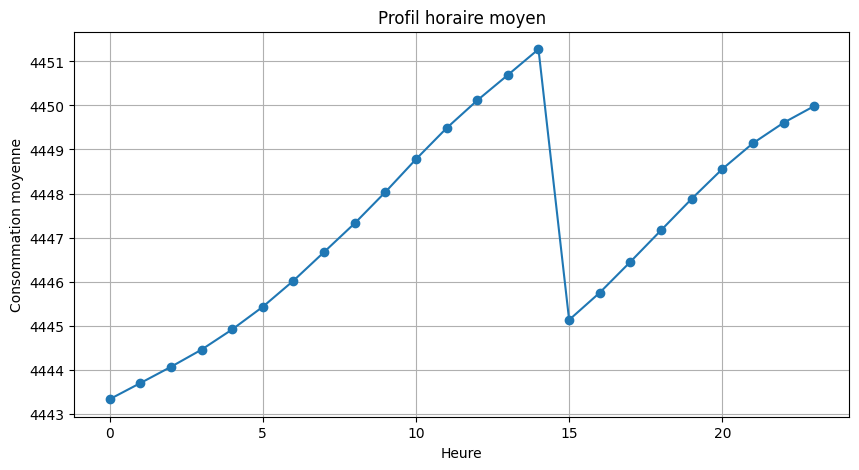

In [34]:
import matplotlib.pyplot as plt

hourly_profile = df.groupby("hour")[target].mean()

plt.figure(figsize=(10,5))
hourly_profile.plot(marker="o")
plt.title("Profil horaire moyen")
plt.xlabel("Heure")
plt.ylabel("Consommation moyenne")
plt.grid(True)
plt.show()

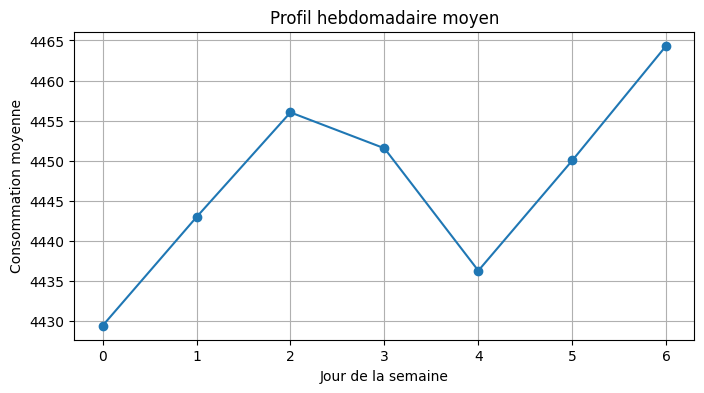

In [35]:
weekly_profile = df.groupby("dayofweek")[target].mean()

plt.figure(figsize=(8,4))
weekly_profile.plot(marker="o")
plt.title("Profil hebdomadaire moyen")
plt.xlabel("Jour de la semaine")
plt.ylabel("Consommation moyenne")
plt.grid(True)
plt.show()

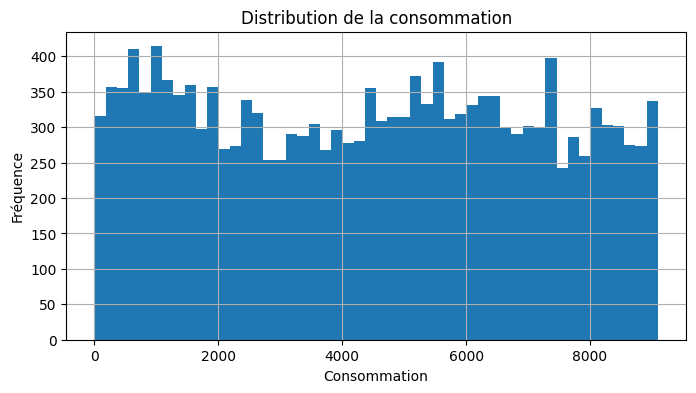

In [37]:
plt.figure(figsize=(8,4))

df[target].hist(bins=50)

plt.title("Distribution de la consommation")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")

plt.show()

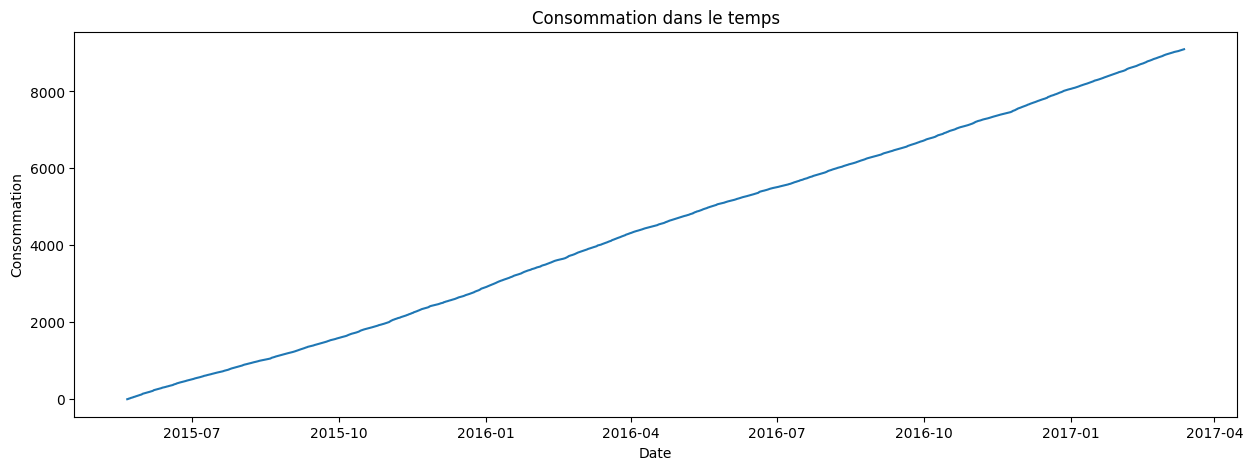

In [38]:
plt.figure(figsize=(15,5))

plt.plot(df["utc_timestamp"], df[target])

plt.title("Consommation dans le temps")
plt.xlabel("Date")
plt.ylabel("Consommation")

plt.show()

In [39]:
X = df[["hour", "dayofweek", "month"]]

y = df[target]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
pred = model.predict(X_test)

In [44]:
df["lag_1"] = df[target].shift(1)

In [45]:
df["lag_24"] = df[target].shift(24)

In [46]:
df["rolling_24"] = (
    df[target]
    .rolling(24)
    .mean()
)

In [47]:
df_ml = df.dropna()

In [54]:
X = df_ml[
    [
        "hour",
        "dayofweek",
        "month",
        "lag_1",
        "lag_24",
        "rolling_24"
    ]
]

y = df_ml[target]

In [53]:
print(X.columns.tolist())
print(X.shape)

['hour', 'dayofweek', 'month', 'lag_1', 'lag_24', 'rolling_24']
(15849, 6)


In [56]:
split = int(len(df_ml) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [60]:
target = "DE_KN_residential1_grid_import"

df = conso[["utc_timestamp", target]].copy()

df = df.dropna()

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

df["hour"] = df["utc_timestamp"].dt.hour
df["dayofweek"] = df["utc_timestamp"].dt.dayofweek
df["month"] = df["utc_timestamp"].dt.month

df["lag_1"] = df[target].shift(1)
df["lag_24"] = df[target].shift(24)

df["rolling_24"] = df[target].rolling(24).mean()

df_ml = df.dropna()

print(df_ml.shape)
df_ml.head()

(15849, 8)


,utc_timestamp,DE_KN_residential1_grid_import,hour,dayofweek,month,lag_1,lag_24,rolling_24
3886,2015-05-22 15:00:00+00:00,15.207,15,4,5,14.875,0.107,7.112167
3887,2015-05-22 16:00:00+00:00,15.602,16,4,5,15.207,0.482,7.742167
3888,2015-05-22 17:00:00+00:00,16.045,17,4,5,15.602,1.045,8.367167
3889,2015-05-22 18:00:00+00:00,16.645,18,4,5,16.045,1.572,8.995208
3890,2015-05-22 19:00:00+00:00,17.362,19,4,5,16.645,2.152,9.628958


In [61]:
X = df_ml[
    [
        "hour",
        "dayofweek",
        "month",
        "lag_1",
        "lag_24",
        "rolling_24"
    ]
]

y = df_ml[target]

print(X.columns.tolist())
print(X.shape)

['hour', 'dayofweek', 'month', 'lag_1', 'lag_24', 'rolling_24']
(15849, 6)


In [62]:
split = int(len(df_ml) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [63]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
pred = model.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("R² :", r2)

MAE : 960.1467088328008
R² : -2.8749132411836635


In [66]:
import pandas as pd

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Variable,Importance
5,rolling_24,3.468720e-01
4,lag_24,3.431198e-01
3,lag_1,3.100030e-01
2,month,4.562830e-06
1,dayofweek,4.896391e-07
0,hour,1.496678e-07


In [67]:
print(df_ml[target].describe())

count    15849.000000
mean      4453.972049
std       2646.980592
min         15.207000
25%       2059.193000
50%       4517.745000
75%       6695.024000
max       9096.383000
Name: DE_KN_residential1_grid_import, dtype: float64


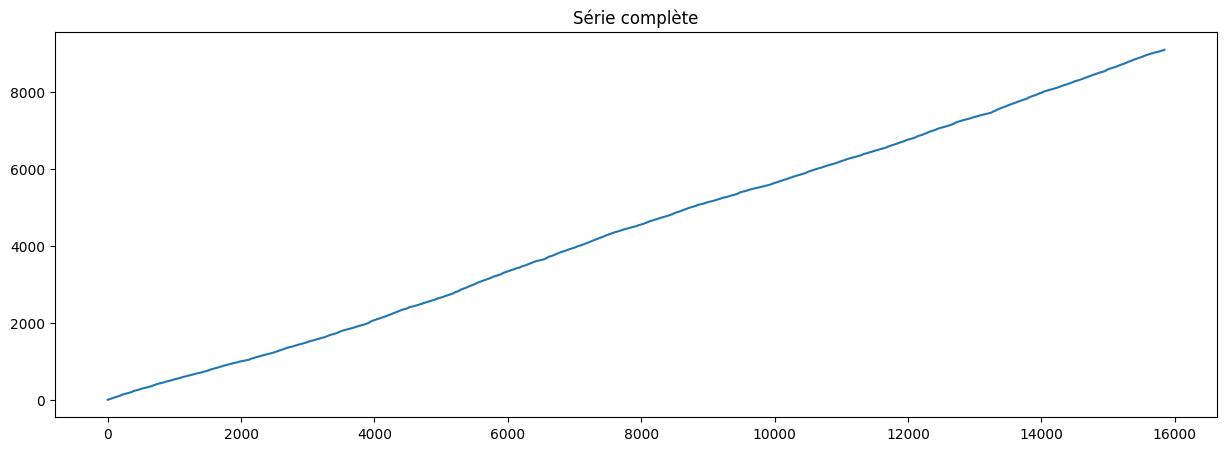

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df_ml[target].values)
plt.title("Série complète")
plt.show()

In [69]:
print(df_ml["utc_timestamp"].min())
print(df_ml["utc_timestamp"].max())

2015-05-22 15:00:00+00:00
2017-03-12 23:00:00+00:00


In [70]:
split = int(len(df_ml) * 0.8)

print(df_ml.iloc[0]["utc_timestamp"])
print(df_ml.iloc[split]["utc_timestamp"])
print(df_ml.iloc[-1]["utc_timestamp"])

2015-05-22 15:00:00+00:00
2016-10-31 22:00:00+00:00
2017-03-12 23:00:00+00:00


In [71]:
comparison = pd.DataFrame({
    "real": y_test.values[:20],
    "pred": pred[:20]
})

comparison

,real,pred
0,7173.048,7172.335780
1,7173.398,7172.335780
2,7173.739,7170.101830
3,7174.118,7170.101830
4,7174.509,7170.101830
5,7174.934,7170.101830
6,7175.393,7170.101830
7,7175.808,7170.101830
8,7176.519,7170.101830
9,7178.043,7170.101830


In [72]:
import numpy as np

print("MAE :", mae)
print("RMSE :", np.sqrt(((y_test - pred) ** 2).mean()))

print("\nRéel")
print(y_test.describe())

print("\nPrédit")
print(pd.Series(pred).describe())

MAE : 960.1467088328008
RMSE : 1114.6990592080203

Réel
count    3170.000000
mean     8130.683644
std       566.363366
min      7173.048000
25%      7632.380500
50%      8128.956000
75%      8620.849000
max      9096.383000
Name: DE_KN_residential1_grid_import, dtype: float64

Prédit
count    3170.000000
mean     7170.536935
std         0.949113
min      7169.450285
25%      7169.567630
50%      7170.127550
75%      7171.493480
max      7172.335780
dtype: float64


In [73]:
comparison.tail(20)

,real,pred
0,7173.048,7172.335780
1,7173.398,7172.335780
2,7173.739,7170.101830
3,7174.118,7170.101830
4,7174.509,7170.101830
5,7174.934,7170.101830
6,7175.393,7170.101830
7,7175.808,7170.101830
8,7176.519,7170.101830
9,7178.043,7170.101830


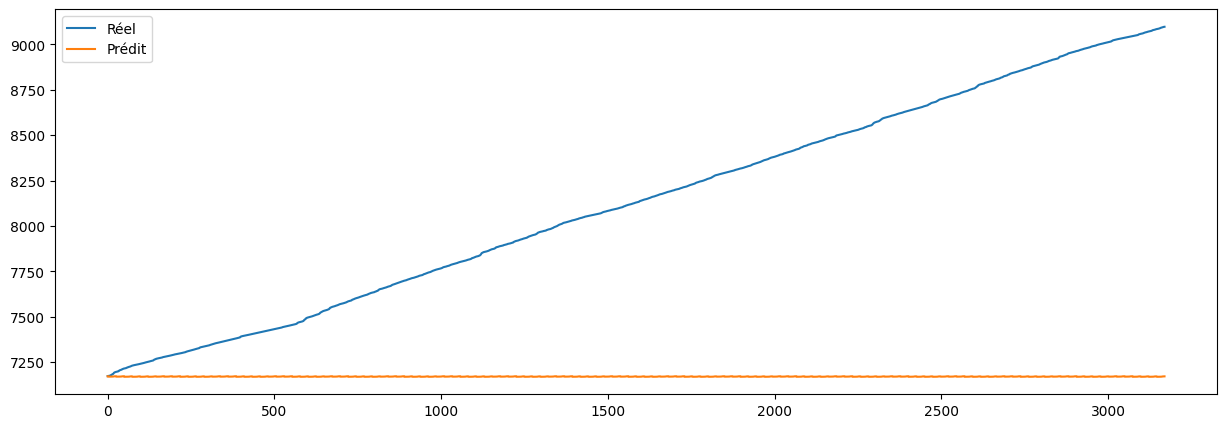

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Réel")
plt.plot(pred, label="Prédit")

plt.legend()
plt.show()

In [75]:
from sklearn.metrics import r2_score

print(r2_score(y_test.values, pred))

-2.8749132411836635


In [76]:
df_ml["conso_horaire"] = df_ml[target].diff()

In [77]:
df_ml = df_ml.dropna()

In [78]:
df_ml["conso_horaire"].describe()

count    15848.000000
mean         0.573017
std          0.367646
min          0.029000
25%          0.375000
50%          0.447000
75%          0.614000
max          4.083000
Name: conso_horaire, dtype: float64

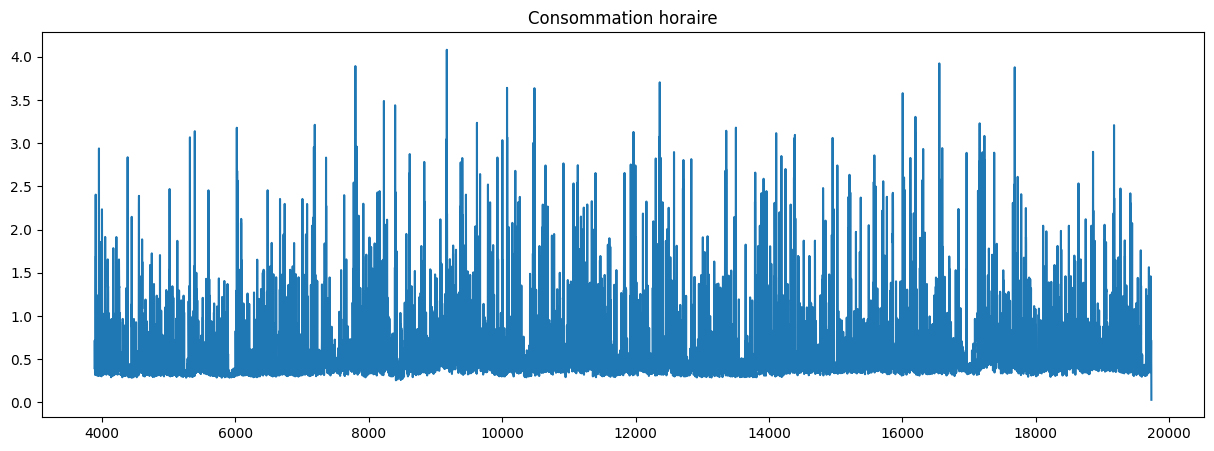

In [79]:
plt.figure(figsize=(15,5))
plt.plot(df_ml["conso_horaire"])
plt.title("Consommation horaire")
plt.show()

In [80]:
y = df_ml[target]

In [81]:
y = df_ml["conso_horaire"]

In [82]:
df_ml["lag_1"] = df_ml["conso_horaire"].shift(1)
df_ml["lag_24"] = df_ml["conso_horaire"].shift(24)
df_ml["rolling_24"] = (
    df_ml["conso_horaire"]
    .rolling(24)
    .mean()
)

In [83]:
df_ml = df_ml.dropna()

In [84]:
df_ml["conso_horaire"] = df_ml[target].diff()
df_ml["conso_horaire"].describe()

count    15823.000000
mean         0.572953
std          0.367431
min          0.029000
25%          0.375000
50%          0.447000
75%          0.614000
max          4.083000
Name: conso_horaire, dtype: float64

In [85]:
df_model = df.copy()

df_model["conso_horaire"] = df_model[target].diff()

df_model["lag_1"] = df_model["conso_horaire"].shift(1)
df_model["lag_24"] = df_model["conso_horaire"].shift(24)

df_model["rolling_24"] = (
    df_model["conso_horaire"]
    .rolling(24)
    .mean()
)

df_model = df_model.dropna()

In [86]:
X = df_model[
    [
        "hour",
        "dayofweek",
        "month",
        "lag_1",
        "lag_24",
        "rolling_24"
    ]
]

y = df_model["conso_horaire"]

In [87]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [88]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [89]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("R² :", r2)

MAE : 0.17758695037928907
R² : 0.27066164664086345


In [90]:
importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Variable,Importance
3,lag_1,0.375670
5,rolling_24,0.219241
4,lag_24,0.169327
0,hour,0.110889
2,month,0.066261
1,dayofweek,0.058611


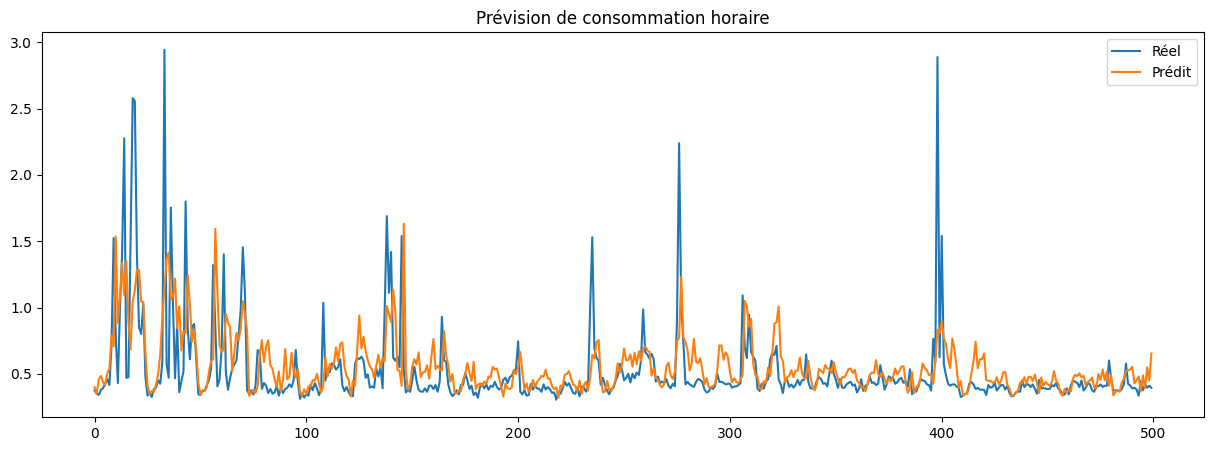

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="Réel")
plt.plot(pred[:500], label="Prédit")

plt.legend()
plt.title("Prévision de consommation horaire")


plt.show()